# Recurrent Neural Networks (RNN)

In [ ]:
-->If we are working on textual data, numerical data we use RNN.
-->It is also used in NLP.
-->RNN is used to solve Sequential Data.
Sequential Data :- The dataset is said to be sequential when the data points are dependent on other data points within a dataset.
                    Example: Time Series Data.
-->In RNN there are two issues :-
            1)The RNN has the short memory.
            2)In RNN vanishing gradient problem may occur.

-->On top of RNN there is another architecture is build it is called Long Short-Term Memory(LSTM)
Long Short-Term Memory(LSTM) :- It has more memory compared to RNN. so it can store more periovs out put. so it can predict the better performance.

# Autoencoders

In [ ]:
-->The role of winzip and winrar are to extract. in winrar it will do comprassion and de compression.

Autoencoders :- It is a type of neural network where the output layer has the same dimensionality as the input layer.
-->In Autoencoders there are three layers :-
              1)Encoder :- It is resposible for down sampling or compression the data automatically reduce the size.
                           
              2)Code/Bottleneck :- After compression the data the output will be called bottleneck means latent space representation.
              
              3)Decoder :-From Code/Bottleneck It is resposible for up sampling or decompress the data.

-->The Autoencoders fall into the catagory of unsupervised learning.
-->The CNN and RNN are fall into the catagory of supervised learning.

-->Applications of Autoencoders :-
    1)Image Denoising
    2)Dimensionality Reduction
    3)Feature Extraction
    4)Image Generation
    5)Image Colorization

In [1]:
# Import the Libararies
from keras.layers import Input, Dense
from keras.models import Model
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Import the dataset
(x_train, _), (x_test, _) = mnist.load_data()

In [3]:
x_train.shape,x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [4]:
# Scaling
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))  #(28*28 = 784)Return the product of array elements over a given axis.
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))



In [5]:
x_train.shape,x_test.shape

((60000, 784), (10000, 784))

In [6]:
input_size = 784
code_size = 32

input_img = Input(shape=(input_size,))


hidden_1 = Dense(128, activation='relu')(input_img)
hidden_2 = Dense(64, activation='relu')(hidden_1)

code = Dense(code_size, activation='relu')(hidden_2)

hidden_3 = Dense(64, activation='relu')(code)
hidden_4 = Dense(128, activation='relu')(hidden_3)

output_img = Dense(input_size, activation='sigmoid')(hidden_4)

autoencoder = Model(input_img, output_img)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')




In [10]:
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3318 - val_loss: 0.1678
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1588 - val_loss: 0.1370
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1359 - val_loss: 0.1243
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1234 - val_loss: 0.1166
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1161 - val_loss: 0.1110
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1116 - val_loss: 0.1073
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1076 - val_loss: 0.1040
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1050 - val_loss: 0.1017
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1030 - val_loss: 0.1000
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1016 - val_loss: 0.0989
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1001 - val_loss: 0.0977
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

In [15]:
def plot_autoencoder_outputs(autoencoder, n, dims):
    decoded_imgs = autoencoder.predict(x_test)

    # number of example digits to show
    n = 10
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # plot original image
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(x_test[i].reshape(*dims))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        

        # plot reconstruction 
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i].reshape(*dims))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
       
    plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


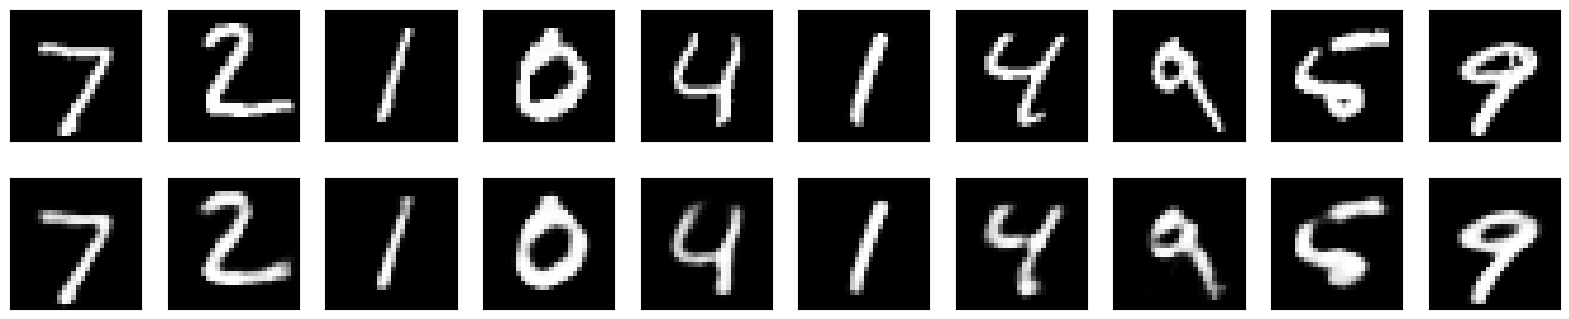

In [17]:
plot_autoencoder_outputs(autoencoder, 10, (28, 28))